# Loading

In [8]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import argparse
from pathlib import Path
import seaborn as sns
import statsmodels.api as sm


K = -1




# # Set the width of your LaTeX document in points
document_width_pt = 511.  # Adjust this according to your LaTeX template
#plt.rc('text', usetex=True)
plt.rc('font', family='serif')
toulouse_color = (132/255, 46/255, 27/255)
missing_color = (0/255, 0/255, 0/255)
label_size = 18
font_size = 15  # Adjust according to your preference
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size+2,
    "xtick.labelsize": font_size-3,
    "ytick.labelsize": font_size-3,
    "legend.fontsize": font_size-3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})





def get_figsize(document_width_pt = document_width_pt, wf=1, hf=0.5):
    """Parameters:
      - wf [float]:  width fraction in columnwidth units
      - hf [float]:  height fraction in columnwidth units.
                     Set by default to golden ratio.
      - columnwidth [float]: width of the column in latex. Get this from LaTeX 
                             using \showthe\columnwidth
    Returns:  [fig_width,fig_height]: that should be given to matplotlib
    """
    fig_width_pt = document_width_pt*wf
    inches_per_pt = 1.0/72.27               # Convert pt to inch
    fig_width = fig_width_pt*inches_per_pt  # width in inches
    fig_height = fig_width*hf      # height in inches
    return [fig_width, fig_height]



# Plots


def load_pi_r(emp_pi_r):
    pi_r = emp_pi_r
    pi_r = np.array([1-sum(pi_r)] + list(pi_r))
    df = filter_N_upstream_df[["ze2010","pi_r"]].drop_duplicates()
    df.loc[~df.pi_r.isna(),"sim_pi_r"] = pi_r
    df.pi_r.fillna(0,inplace = True)
    df.sim_pi_r.fillna(0,inplace = True)
    return df



def plot_downstream(df,col_name,ax,fig):

    tmp = france.merge(df,on = "ze2010",how = "left")
    tmp[col_name].fillna(0,inplace = True)
    
    if col_name != "productivity":
        vmin = min(df.query('pi_r >0')["pi_r"].to_list())#+df.query('sim_pi_r >0')["sim_pi_r"].to_list())
        vmax = max(df["pi_r"].to_list()+df["sim_pi_r"].to_list())
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else: 
        vmin,vmax = min(df.query('productivity >0').productivity),max(df['productivity'])
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        print(df.productivity.describe())

    tmp.query(col_name+' == 0').plot(color = "gray",ax=ax)
    tmp.query(col_name+' > 0').plot(column = col_name,ax=ax,norm = norm, cmap = "viridis",edgecolor ="black")

    ax_inset = inset_axes(ax, width="65%", height="65%", loc="upper right",bbox_to_anchor=(0.745, 0.775, 0.25, 0.25), bbox_transform=ax.transAxes, borderpad=1)  
    data_idf = tmp[tmp['ze2010'].isin(idf_ze)]
    data_idf.query(col_name+' == 0').plot(color = "gray",ax=ax_inset)
    data_idf.query(col_name+' > 0').plot(column = col_name,ax=ax_inset,norm = norm, cmap = "viridis",edgecolor ="black")

    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax.set_xlim(-5, 10)
    ax.set_ylim(42, 52)
    ax.set_xticks([])
    ax.set_yticks([])

    add_colorbar(ax,fig,norm)
    return norm

def load_productivity(file_name):
    prod = np.load(os.path.join(folder,f"{file_name}.npy"))
    df = filter_N_upstream_df[["ze2010","pi_r"]].drop_duplicates()
    df.loc[~df.pi_r.isna(),"productivity"] = prod
    df.productivity.fillna(0,inplace = True)
    return df

def add_colorbar(ax,fig,norm):
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.02, pad=0.04, aspect=50, format='%1.4f')
    cbar.minorticks_off()

def load_productivity(productivity):
    prod = productivity
    df = filter_N_upstream_df[["ze2010","pi_r"]].drop_duplicates()
    df.loc[~df.pi_r.isna(),"productivity"] = prod
    df.productivity.fillna(0,inplace = True)
    return df

def unpack_simulated_moments(sim_moments, empirical_moments):
    keys = [
        "agg_labor_share",
        "agg_industry_share",
        "emp_gamma_ls",
        "reg_coef",
        "emp_pi_r"
    ]

    sizes = [m.size for m in empirical_moments]
    splits = np.cumsum(sizes)[:-1]
    blocks = np.split(sim_moments, splits, axis=0)

    return {
        k: b.reshape(m.shape + (b.shape[1],))
        for k, m, b in zip(keys, empirical_moments, blocks)
    }


def unpack_params(params, S = 9, R_downstream = 35):
    """
    This function takes a vector of parameters and returns the parameters
    as separated variables.
    """

    beta = params[0:5]
    labor_share_tech = params[5]

    input_share_tech = params[6:6+S]
    input_share_tech = input_share_tech / np.sum(input_share_tech)

    productivity_ = params[6+S : 6+S+R_downstream]
    T_ = params[6+S+R_downstream :]

    return {"beta":beta, "labor_share_tech":labor_share_tech, "input_share_tech":input_share_tech, "productivity":productivity_, "T":T_}
def bubble_scatter(ax, x, y, xlabel, ylabel, title, size_scale=300,regression_line = False):
    mask = x > 0
    x, y = x[mask], y[mask]

    sizes = size_scale * x / x.max()
    lims = [min(x.min(), y.min())*1.2, max(x.max(), y.max())*1.2]
    data = pd.DataFrame({"x":x,"y":y})

    

    ax.scatter(x, y, s=sizes, alpha=0.6, edgecolor="black",color = toulouse_color)
    
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(linestyle = "dashed",alpha = 0.5)
    ols = sm.OLS.from_formula('y ~0+ x', data=data).fit()
    b = ols.params[0]
    ax.text(0.98, 0.09, fr'Coefficient: ${np.round(ols.params[-1],3)}$', ha='right', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)
    ax.text(0.98, 0.01, fr't-stat: ${np.round(ols.tvalues[-1],1)}$', ha='right', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)
    
    if regression_line:
        X = np.linspace(0,1,100)
        Y = b*X
        ax.plot(X, Y, linestyle='--', color='green')  # '--' for dashed line, linewidth for thickness
    else :
        ax.plot(lims, lims, color="black")
    print(lims)

    sns.despine()


<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_210553/4096805346.py:49: SyntaxWarning: invalid escape sequence '\s'
  using \showthe\columnwidth


In [9]:
# Loading
# --- Paths ---
industry = "auto_23"  # or "auto_24"
industry_name = "auto"
input_folder = Path(f"../baseline_{industry}")

# --- Load only what is used ---
coefs = pd.read_csv(input_folder / "stats.csv")

agg_labor_share = coefs.loc[1, "value"]          # coefs[2,"value"] in Julia
epsilon = coefs.loc[0, "value"]                  # coefs[1,"value"]

agg_industry_share = np.load(input_folder / "input_share.npy")
emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy").T
emp_pi_r = np.load(input_folder / "emp_pi_r.npy")[1:]
reg_coef = np.load(input_folder / "reg_coef.npy")

# --- Empirical moments (same ordering as Julia) ---
reference_empirical_moments = [
    np.array([agg_labor_share]),
    agg_industry_share[1:],   # Julia [2:end]
    emp_gamma_ls,
    reg_coef,
    emp_pi_r
]



idf_ze = ['1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
       '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
       '1113', '1108', '1107']

       
filter_N_upstream_df = pd.read_csv(os.path.join(input_folder,"filter_N_upstream.csv"))
filter_N_upstream_df.ze2010 = filter_N_upstream_df.ze2010.astype(str).str.zfill(4)


distances = np.load(os.path.join(input_folder,"full_distances.npy"))

france = gpd.read_file(os.path.join(input_folder,"france.shp")).sort_values(by = 'ze2010')

ref = pd.DataFrame(distances[:297,:297], index=france["ze2010"].values, columns=france["ze2010"].values)
ref.reset_index(inplace=True)
ref.rename(columns={'index': 'ze2010_i'}, inplace=True)
ref = ref.melt(id_vars='ze2010_i', var_name='ze2010_j', value_name='M_ij')


In [10]:
# Importation 

folder = f"../reporting_{industry}/"
empirical_moments = np.load(os.path.join(folder,f"empirical_moments.npy"))
best_simulated_moments = np.load(os.path.join(folder,f"best_simulated_moments.npy"))
best_params = np.load(os.path.join(folder,f"best_parameters_list.npy"))


best_simulated_moments_dict = unpack_simulated_moments(best_simulated_moments, reference_empirical_moments)
empirical_moments_dict = unpack_simulated_moments(empirical_moments.T, reference_empirical_moments)
K = -1

empirical_moments_dict

{'agg_labor_share': array([[0.19682219]]),
 'agg_industry_share': array([[0.0898495 ],
        [0.10642199],
        [0.14475087],
        [0.31774101],
        [0.2100454 ],
        [0.08217691]]),
 'emp_gamma_ls': array([[[4.17183645e-03],
         [2.39896912e-04],
         [9.00521946e-04],
         ...,
         [3.31806010e-04],
         [1.74684447e-03],
         [0.00000000e+00]],
 
        [[0.00000000e+00],
         [2.90657421e-03],
         [0.00000000e+00],
         ...,
         [0.00000000e+00],
         [4.57463461e-05],
         [0.00000000e+00]],
 
        [[2.10801402e-05],
         [0.00000000e+00],
         [0.00000000e+00],
         ...,
         [0.00000000e+00],
         [0.00000000e+00],
         [0.00000000e+00]],
 
        ...,
 
        [[0.00000000e+00],
         [0.00000000e+00],
         [0.00000000e+00],
         ...,
         [0.00000000e+00],
         [0.00000000e+00],
         [0.00000000e+00]],
 
        [[0.00000000e+00],
         [0.00000000e+00],


In [11]:
import os
import numpy as np
import pandas as pd

# --- Panel A: Aggregate Labor Share ---
panel_A = pd.DataFrame({
    "Sector": ["Aggregate Labor Share"],
    "Empirical": [np.round(agg_labor_share, 4)],
    "Simulated": [np.round(best_simulated_moments_dict['agg_labor_share'][:, K][0], 4)]
})

# --- Panel B: Aggregate Industry Shares ---
# Load industry names
name_A129 = pd.read_csv("../external/A129_name_fr_eng.csv")

# Simulated shares (including residual sector if needed)
sim_agg_industry_share = [1 - np.sum(best_simulated_moments_dict['agg_industry_share'][:, K])] + list(best_simulated_moments_dict['agg_industry_share'][:, K])

# Individual sector codes
A129_codes = list(filter_N_upstream_df['A129'].drop_duplicates().sort_values())

industry_share = pd.DataFrame({
    "A129": A129_codes,
    "Empirical": list(np.round(agg_industry_share, 4)),
    "Simulated": np.round(sim_agg_industry_share, 4)
})

# Merge with names
industry_share = industry_share.merge(name_A129, on="A129", how="left")
industry_share["name"] = industry_share["name"].fillna("Aggregate / Non-upstream sector")
industry_share = industry_share.rename(columns={"name": "Sector"})
industry_share = industry_share[["Sector", "Empirical", "Simulated"]]

# --- Panel C: Regression Coefficients ---

coef_names = [r'$]20,50]$', r'$]50,100]$', r'$]100,150]$', r'$]150,200]$', r'$ > 200$'] if industry == "aero" else [ r'$]50,100]$', r'$]100,150]$', r'$]150,200]$', r'$ > 200$']

panel_C = pd.DataFrame({
    "Coefficient": coef_names,
    "Empirical": np.round(reg_coef, 3),
    "Simulated": np.round(best_simulated_moments_dict['reg_coef'][:, K], 3)
})

# --- Generate LaTeX Table ---
def df_to_latex(panel, panel_name, col1_name):
    latex = f"\\multicolumn{{3}}{{l}}{{\\textbf{{{panel_name}}}}} \\\\\n"
    latex += "\\midrule\n"
    latex += f"{col1_name} & {{Empirical}} & {{Simulated}} \\\\\n"
    latex += "\\midrule\n"
    for i, row in panel.iterrows():
        latex += f"{row[0]} & {row[1]:.4f} & {row[2]:.4f} \\\\\n"
    latex += "\\bottomrule\n\\addlinespace[0.5em]\n"
    return latex

latex_table = r"""\begin{table}[!htbp]
\centering
\caption{Empirical and Simulated Moments}
\label{tab:moments_comparison_""" + f"{industry}" + r"""}
\renewcommand{\arraystretch}{1.2} % row spacing
\small
\begin{tabular}{
l
S[table-format=1.4] 
S[table-format=1.4]
}
\toprule
"""

latex_table += df_to_latex(panel_A, "Panel A: Aggregate Labor Share", "")
latex_table += df_to_latex(industry_share, "Panel B: Aggregate Industry Shares", "Sector")

# Panel C: Regression coefficients
latex_table += f"\\multicolumn{{3}}{{l}}{{\\textbf{{Panel C: Regression Coefficients}}}} \\\\\n"
latex_table += "\\midrule\n"
latex_table += "Coefficient & {Empirical} & {Simulated} \\\\\n"
latex_table += "\\midrule\n"
for i, row in panel_C.iterrows():
    latex_table += f"{row[0]} & {row[1]:.3f} & {row[2]:.3f} \\\\\n"
latex_table += "\\bottomrule\n"

latex_table += r"""\end{tabular}

\vspace{0.3cm}
\caption*{\footnotesize \emph{Notes}: This table compares empirical moments (Column~2) with moments simulated from the model calibrated on the """ + f"{industry_name}" + r""" industry. Panel A shows the aggregate labor share, Panel B shows sectoral industry shares, and Panel C shows regression coefficients estimated empirically using Equation~\ref{eq:reduced_form_spatialIO} on a finer distance bins. Shares are rounded to 4 decimals, coefficients to 3 decimals.}
\end{table}
"""

# Save to file
output_file = os.path.join(folder, f"moments_comparison_{industry}.tex")
with open(output_file, "w") as f:
    f.write(latex_table)


/tmp/ipykernel_210553/4049396725.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  latex += f"{row[0]} & {row[1]:.4f} & {row[2]:.4f} \\\\\n"
/tmp/ipykernel_210553/4049396725.py:78: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  latex_table += f"{row[0]} & {row[1]:.3f} & {row[2]:.3f} \\\\\n"


/tmp/ipykernel_210553/4096805346.py:68: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.pi_r.fillna(0,inplace = True)
/tmp/ipykernel_210553/4096805346.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

[np.float64(0.0), np.float64(0.41922935468434813)]


/tmp/ipykernel_210553/4096805346.py:182: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = ols.params[0]
/tmp/ipykernel_210553/4096805346.py:183: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(0.98, 0.09, fr'Coefficient: ${np.round(ols.params[-1],3)}$', ha='right', va='bottom', fontsize=10, color='black', transform=plt.gca().transAxes)
/tmp/ipykernel_210553/4096805346.py:184: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.t

[np.float64(1.3151363615521746e-06), np.float64(0.21652438892610912)]


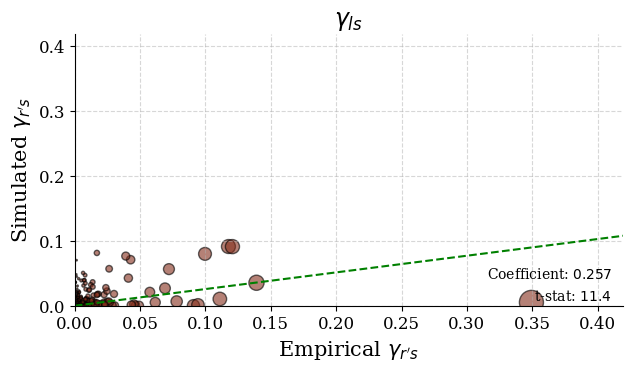

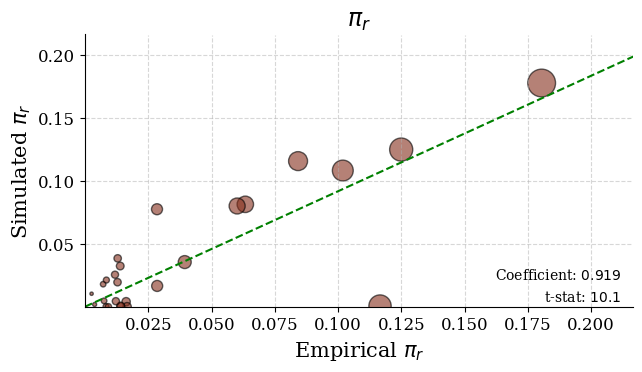

In [12]:
emp_g = empirical_moments_dict['emp_gamma_ls'].ravel()
sim_g = best_simulated_moments_dict['emp_gamma_ls'][:, :, K].ravel()

pi_r = load_pi_r(best_simulated_moments_dict['emp_pi_r'][:, K])

emp_pi = pi_r.pi_r.values
sim_pi = pi_r.sim_pi_r.values


    
fig, axs = plt.subplots(1, 1, figsize=get_figsize())

bubble_scatter(
    axs,
    emp_g,
    sim_g,
    r"Empirical $\gamma_{r's}$",
    r"Simulated $\gamma_{r's}$",
    r"$\gamma_{ls}$",regression_line = True
)

fig.savefig(os.path.join(folder, f'emp_sim_gamma_{industry}.pdf'), format='pdf', bbox_inches='tight')

fig, axs = plt.subplots(1, 1, figsize=get_figsize())

bubble_scatter(
    axs,
    emp_pi,
    sim_pi,
    r"Empirical $\pi_{r}$",
    r"Simulated $\pi_{r}$",
    r"$\pi_{r}$",
    size_scale=400,regression_line = True
)
fig.savefig(os.path.join(folder, f'emp_sim_pi_{industry}.pdf'), format='pdf', bbox_inches='tight')


/tmp/ipykernel_210553/4096805346.py:77: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tmp[col_name].fillna(0,inplace = True)
/tmp/ipykernel_210553/4096805346.py:77: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

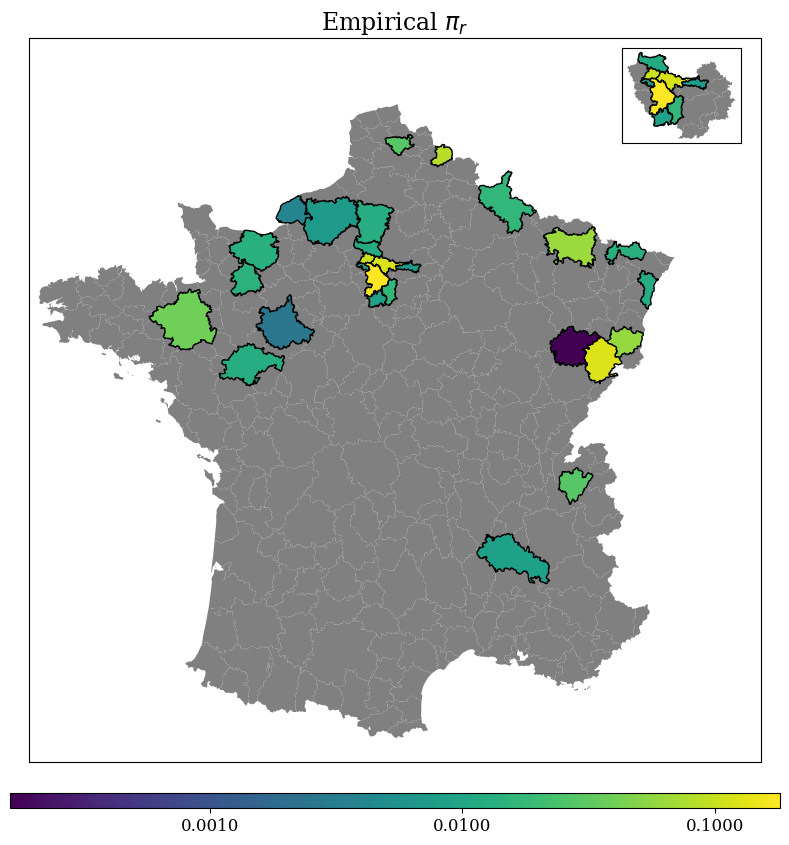

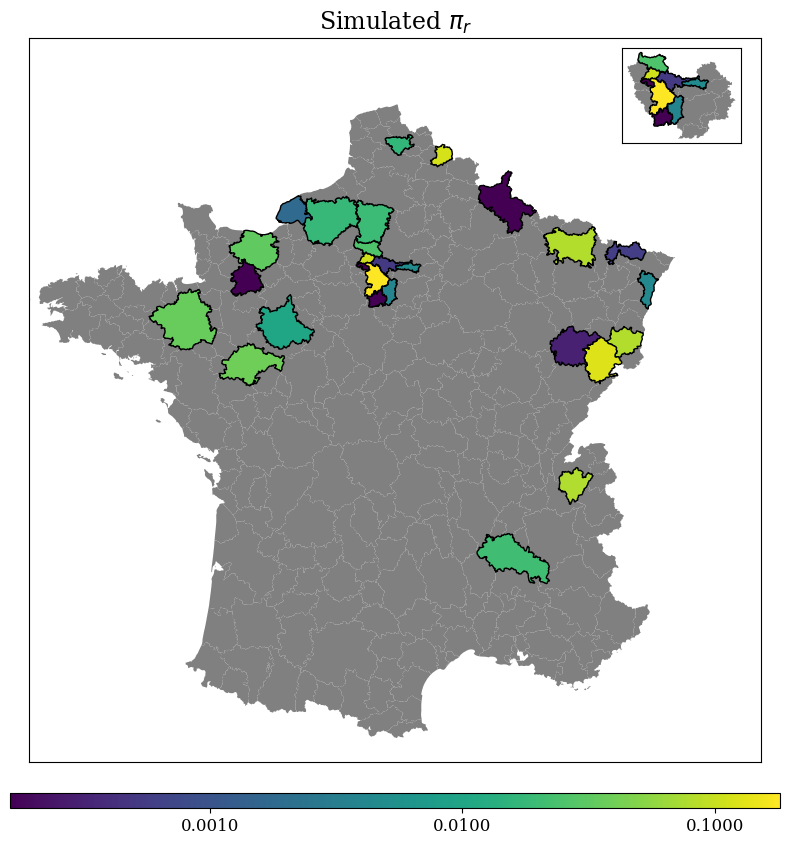

In [13]:
fig,axs = plt.subplots(1,1,figsize = (15,10))

plot_downstream(pi_r, "pi_r", axs,fig)
axs.set_title(r"Empirical $\pi_{r}$ ")
fig.savefig(os.path.join(folder, f"emp_pi_r_{industry}.png"), bbox_inches='tight')

fig,axs = plt.subplots(1,1,figsize = (15,10))
plot_downstream(pi_r, "sim_pi_r",axs,fig)
axs.set_title(r"Simulated $\pi_{r}$ ")
fig.savefig(os.path.join(folder, f"sim_pi_r_{industry}.png"), bbox_inches='tight')

# Loss function

Text(0.5, 1.0, 'Loss function')

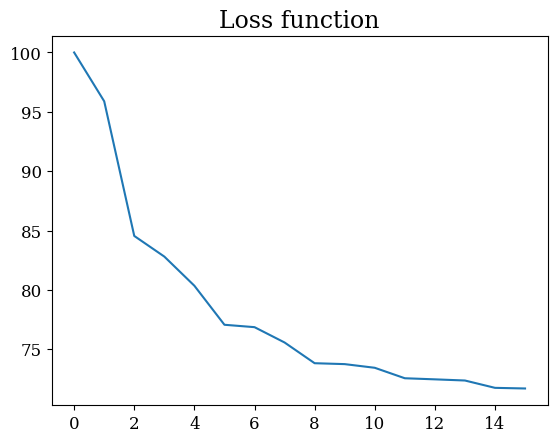

In [14]:
loss_function = np.sum((empirical_moments.T-best_simulated_moments)**2,axis = 0)
loss_function/=loss_function[0]/100


plt.plot(loss_function)
plt.title('Loss function')

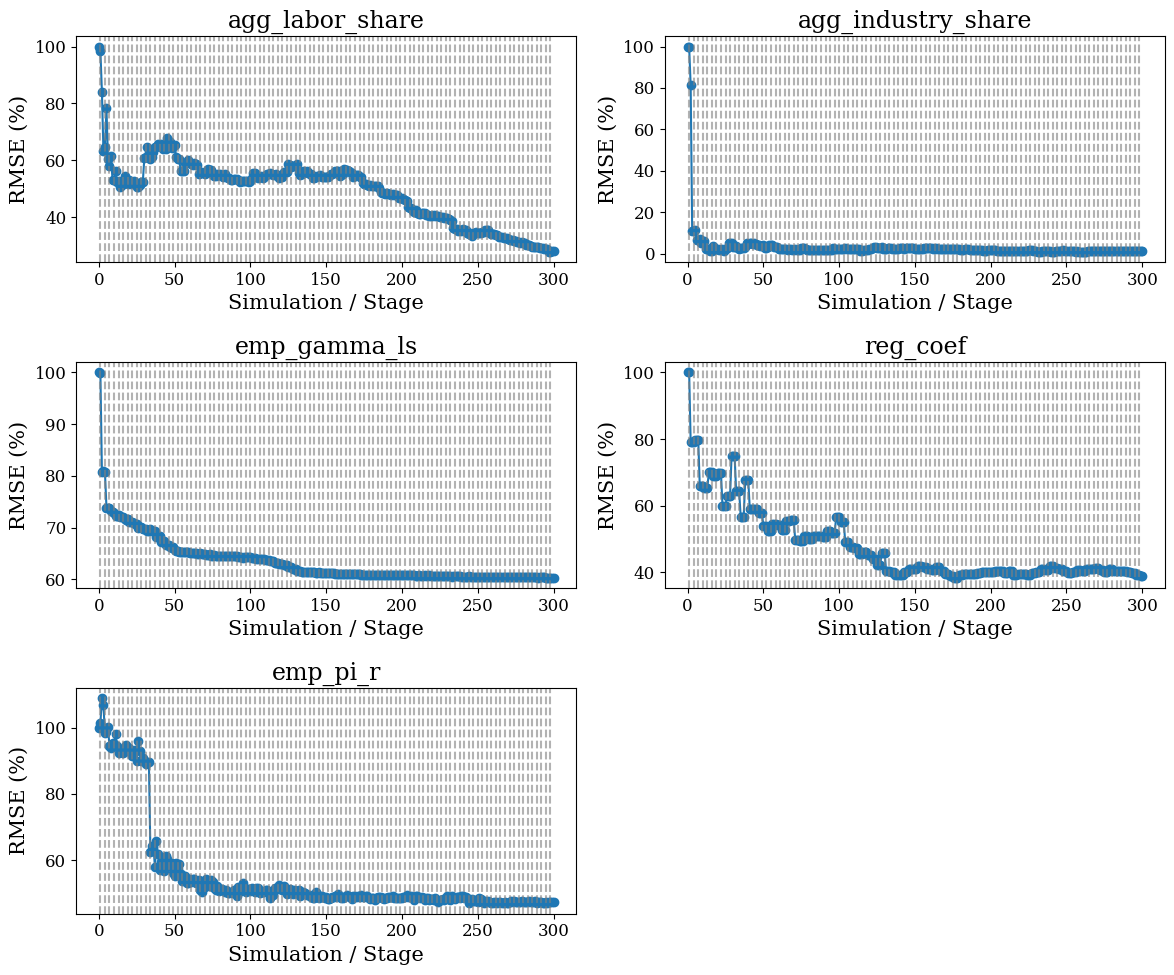

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2, axis=0))

moment_names = list(empirical_moments_dict.keys())
loss_dict = {}

# --- Compute RMSE and normalize ---
for key in moment_names:
    emp = empirical_moments_dict[key]
    sim = best_simulated_moments_dict[key]  # shape: (*shape_emp, n_sim)
    
    emp_flat = emp.ravel()[:, np.newaxis]          # shape (K, 1)
    sim_flat = sim.reshape(-1, sim.shape[-1])     # shape (K, n_sim)
    
    loss = rmse(emp_flat, sim_flat)
    loss_norm = 100 * loss / loss[0]  # normalize to 100% at stage 0
    loss_dict[key] = loss_norm

# --- Plot in 3x2 subplots ---
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
n_stages = len(next(iter(loss_dict.values())))  # number of stages

for i, key in enumerate(moment_names):
    ax = axes[i]
    ax.plot(loss_dict[key], marker='o')
    ax.set_title(key)
    ax.set_xlabel("Simulation / Stage")
    ax.set_ylabel("RMSE (%)")
    ax.grid(False)
    
    # Vertical dashed lines every 3 stages, starting at stage 1
    for vline in range(1, n_stages, 3):
        ax.axvline(vline, color='gray', linestyle='--', alpha=0.6)

# Hide unused subplot if less than 6 moments
if len(moment_names) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


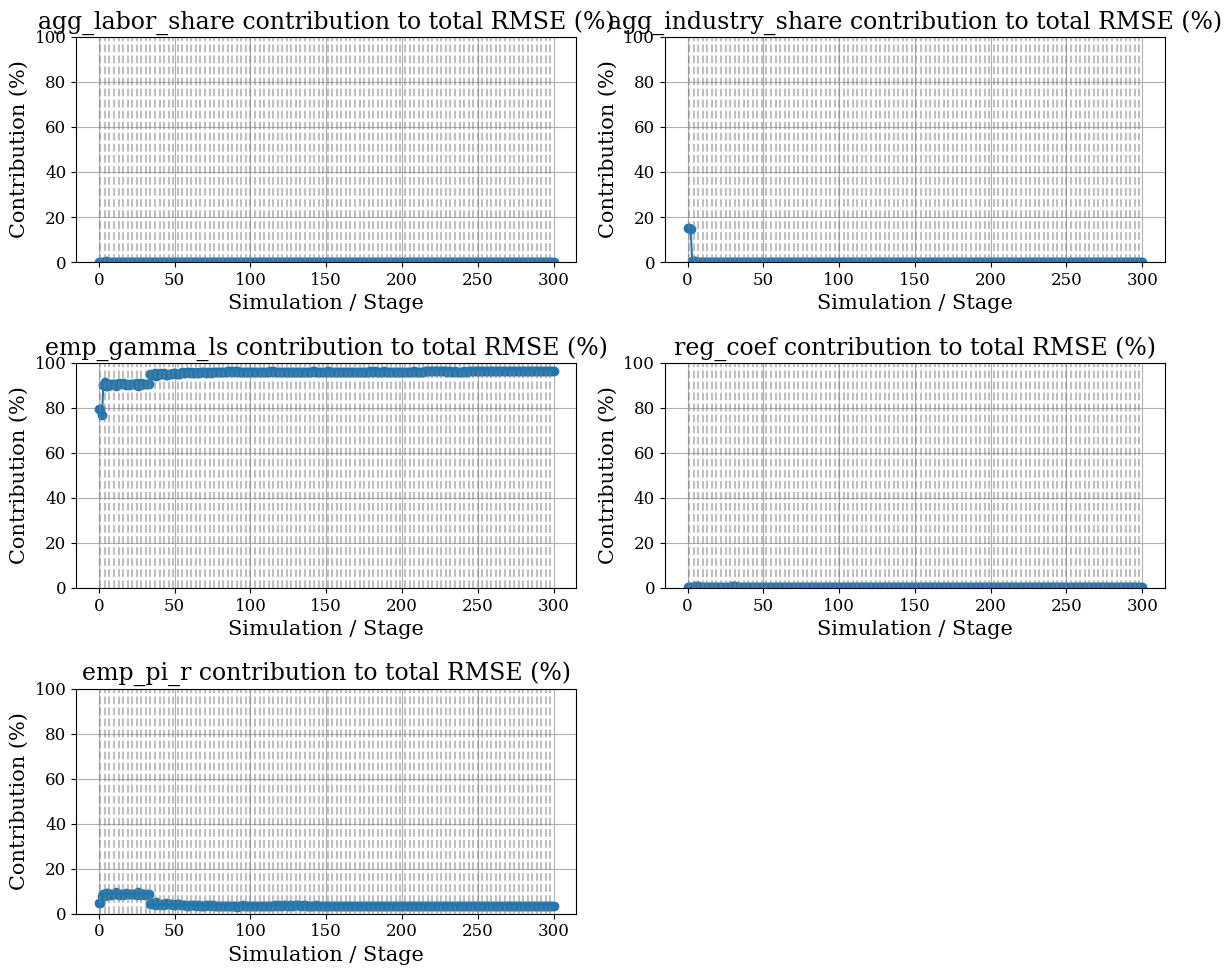

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def squared_error(y_true, y_pred):
    """Compute sum of squared errors along all spatial dimensions."""
    return np.sum((y_true.ravel()[:, np.newaxis] - y_pred.reshape(-1, y_pred.shape[-1]))**2, axis=0)

moment_names = list(empirical_moments_dict.keys())
n_stages = next(iter(best_simulated_moments_dict.values())).shape[-1]

# --- Compute contribution of each type ---
contrib_dict = {key: np.zeros(n_stages) for key in moment_names}
total_se = np.zeros(n_stages)

for key in moment_names:
    emp = empirical_moments_dict[key]
    sim = best_simulated_moments_dict[key]  # shape: (*shape_emp, n_stages)
    
    se = squared_error(emp, sim)  # shape: (n_stages,)
    contrib_dict[key] = se
    total_se += se

# --- Compute % contribution ---
for key in moment_names:
    contrib_dict[key] = 100 * contrib_dict[key] / total_se

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, key in enumerate(moment_names):
    ax = axes[i]
    ax.plot(contrib_dict[key], marker='o')
    ax.set_title(f"{key} contribution to total RMSE (%)")
    ax.set_xlabel("Simulation / Stage")
    ax.set_ylabel("Contribution (%)")
    ax.set_ylim(0, 100)
    ax.grid(True)
    
    # Vertical dashed lines every 3 stages
    for vline in range(1, n_stages, 3):
        ax.axvline(vline, color='gray', linestyle='--', alpha=0.5)

# Hide unused subplot if less than 6 moments
if len(moment_names) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


# Gamma_ls 

In [ ]:
K = -1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

emp = empirical_moments_dict['emp_gamma_ls']
best = best_simulated_moments_dict['emp_gamma_ls'][:, :, K]

x = emp.ravel()
y = best.ravel()

# Keep only non-zero empirical observations
mask = (x != 0)
x, y = x[mask], y[mask]

# Bubble sizes (scaled for visibility)
sizes = 300 * (x / x.max())

# Threshold for top 20% empirical values
threshold = np.percentile(x, 80)
top_mask = x >= threshold

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Subplot 1: Full bubble plot ----
axes[0].scatter(
    x, y,
    s=sizes,
    alpha=0.5,
    edgecolor="black"
)

lims_full = [
    min(x.min(), y.min()),
    max(x.max(), y.max())
]
axes[0].plot(lims_full, lims_full, color="black")
axes[0].set_xlim(lims_full)
axes[0].set_ylim(lims_full)

axes[0].set_xlabel(r"Empirical $\gamma_{ls}$")
axes[0].set_ylabel(r"Simulated $\gamma_{ls}$")
axes[0].set_title("Bubble plot – all observations")

# ---- Subplot 2: Top 20% empirical bubble plot ----
axes[1].scatter(
    x[top_mask], y[top_mask],
    s=sizes[top_mask],
    alpha=0.5,
    edgecolor="black"
)

lims_top = [
    min(x[top_mask].min(), y[top_mask].min()),
    max(x[top_mask].max(), y[top_mask].max())
]
axes[1].plot(lims_top, lims_top, color="black")
axes[1].set_xlim(lims_top)
axes[1].set_ylim(lims_top)

axes[1].set_xlabel(r"Empirical $\gamma_{ls}$")
axes[1].set_ylabel(r"Simulated $\gamma_{ls}$")
axes[1].set_title("Bubble plot – top 20% empirical")

plt.tight_layout()
plt.show()


In [ ]:
empirical_moments_dict

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# --- Data ---
emp = empirical_moments_dict['emp_gamma_ls'].ravel()
sim = best_simulated_moments_dict['emp_gamma_ls'][:, :, K].ravel()

# keep positive (and non-zero) moments
emp_nz = emp[emp >= 0.01]
sim_nz = sim[sim >= 0.01]

# --- CDF (log-log) ---
xmin = min(emp_nz.min(), sim_nz.min())
xmax = max(emp_nz.max(), sim_nz.max())
x_vals = np.linspace(xmin, xmax, 300)
x_vals = x_vals[x_vals > 0]

F_emp = ECDF(emp_nz)
F_sim = ECDF(sim_nz)

cdf_emp = F_emp(x_vals)
cdf_sim = F_sim(x_vals)

keep = (cdf_emp > 0) & (cdf_sim > 0)

# --- Histogram threshold ---
x_chi = np.quantile(emp[emp != 0], 0.9)

emp_tail = emp[emp > x_chi]
sim_tail = sim[sim > x_chi]

bins = np.linspace(x_chi, max(emp_tail.max(), sim_tail.max()), 31)

# --- Plot ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# CDF
ax[0].plot(x_vals[keep], cdf_emp[keep], label="Empirical")
ax[0].plot(x_vals[keep], cdf_sim[keep], label="Simulated")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$\gamma_{ls}$")
ax[0].set_ylabel("CDF")
ax[0].set_title("Log-Log CDF of $\gamma_{ls}$")
ax[0].legend()

# Distribution
ax[1].hist(emp_tail, bins=bins, alpha=0.5, label="Empirical")
ax[1].hist(sim_tail, bins=bins, alpha=0.5, label="Simulated")
ax[1].set_title(r"$\gamma_{ls}$ (upper tail)")
ax[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
empirical_moments_dict

In [ ]:

# --- Take the positive, non-zero values ---
emp = empirical_moments_dict['emp_gamma_ls'].ravel()
sim = best_simulated_moments_dict['emp_gamma_ls'][:, :, -1].ravel()

mask = emp > 0.0  # keep regions with non-zero empirical gamma
emp_nz = emp[mask]
sim_nz = sim[mask]

# --- Create DataFrame ---
df = pd.DataFrame({
    "empirical_gamma_ls": emp_nz,
    "simulated_gamma_ls": sim_nz
})

# --- Describe distributions ---
description = df.describe()
print(description)


In [ ]:
tmp = pd.DataFrame(np.ndarray.flatten(empirical_moments_dict['emp_gamma_ls']),columns= ["emp_gamma_ls"])
print(tmp.query("emp_gamma_ls==0").shape)
tmp.query('emp_gamma_ls!= 0').describe()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw

# ------------------------------------------------------------------
# 1. Extract non-zero, positive data
# ------------------------------------------------------------------
x = tmp.loc[tmp['emp_gamma_ls'] != 0, 'emp_gamma_ls'].values
x = x[x > 0]

# ------------------------------------------------------------------
# 2. Log–log CCDF (diagnostic)
# ------------------------------------------------------------------
x_sorted = np.sort(x)
ccdf = 1.0 - np.arange(1, len(x_sorted) + 1) / len(x_sorted)

plt.figure()
plt.loglog(x_sorted, ccdf, marker='.', linestyle='none')
plt.xlabel("emp_gamma_ls")
plt.ylabel("P(X ≥ x)")
plt.title("Log–log CCDF of non-zero emp_gamma_ls")
plt.show()

# ------------------------------------------------------------------
# 3. Power-law fit (MLE)
# ------------------------------------------------------------------
fit = powerlaw.Fit(x, discrete=False, verbose=False)

alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print(f"Power-law alpha: {alpha:.4f}")
print(f"Power-law xmin : {xmin:.4f}")

# ------------------------------------------------------------------
# 4. Goodness-of-fit: power law vs lognormal
# ------------------------------------------------------------------
R, p = fit.distribution_compare('power_law', 'lognormal')

print(f"Likelihood ratio (power law vs lognormal): R = {R:.4f}")
print(f"p-value: {p:.4f}")

# ------------------------------------------------------------------
# 5. Visual comparison of CCDFs
# ------------------------------------------------------------------
fig = fit.plot_ccdf(label='Empirical')
fit.power_law.plot_ccdf(ax=fig, linestyle='--', label='Power law')
fit.lognormal.plot_ccdf(ax=fig, linestyle=':', label='Lognormal')
plt.legend()
plt.show()


# A_r

We search to compute 
$$
\begin{aligned}
\mathcal{A}_{r'}^{\text{Local}}
&= \frac{\sum_{s\neq d} \left(w_s^{r'} w_d^{sr'} w_{r'}^{sr'd}\right)^2}
{(w_d^{r'})^2 + \sum_{s\neq d} (w_s^{r'})^2} = \frac{1}{H_h^{r'}} 
\underbrace{\sum_{s\neq d} (w_s^{r'})^2 \left(w_d^{sr'} w_{r'}^{sr'd}\right)^2}_{H_v^{r'}} .
\end{aligned}
$$

We search to compute 
$$
\begin{aligned}
\mathcal{A}_{r'}^{\text{All}} 
&= \frac{\sum_{r}\sum_{s\neq d} \left(w_s^{r'} w_d^{sr'} w_{r}^{sr'd}\right)^2}
{(w_d^{r'})^2 + \sum_{s\neq d} (w_s^{r'})^2} = \frac{1}{H_h^{r'}} 
\underbrace{\sum_{s\neq d} (w_s^{r'} w_d^{sr'})^2 \sum_{r} (w_{r}^{sr'd})^2}_{H_v^{r'}} .
\end{aligned}
$$

In [16]:
w_sr_d_sr = pd.read_csv(os.path.join(input_folder,"w_sr_d_sr.csv"))
w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
w_sr_d_sr = w_sr_d_sr.drop(columns="_merge")


w_srd_r = np.load(os.path.join(folder,"w_srd_r.npy")) # S x R' x R
upstream_A129_region = pd.read_csv(os.path.join(input_folder,"upstream_A129_region.csv")).query('ze2010 != 9999')
upstream_A129_region['ze2010']  = upstream_A129_region.ze2010.astype(str).str.zfill(4)
df = filter_N_upstream_df[['A129',"ze2010"]].merge(filter_N_upstream_df[['A129',"ze2010"]],on = ['A129'],suffixes = ['_r_prime','_r'])
df["w_srd_r"] = np.ndarray.flatten(w_srd_r)

df['w_srd_r_2'] = df.w_srd_r**2
df = df.groupby(['A129',"ze2010_r_prime"]).w_srd_r_2.sum().reset_index()

/tmp/ipykernel_50190/720450650.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  A_r.w_srd_r_2.fillna(0,inplace = True)
/tmp/ipykernel_50190/1526584745.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

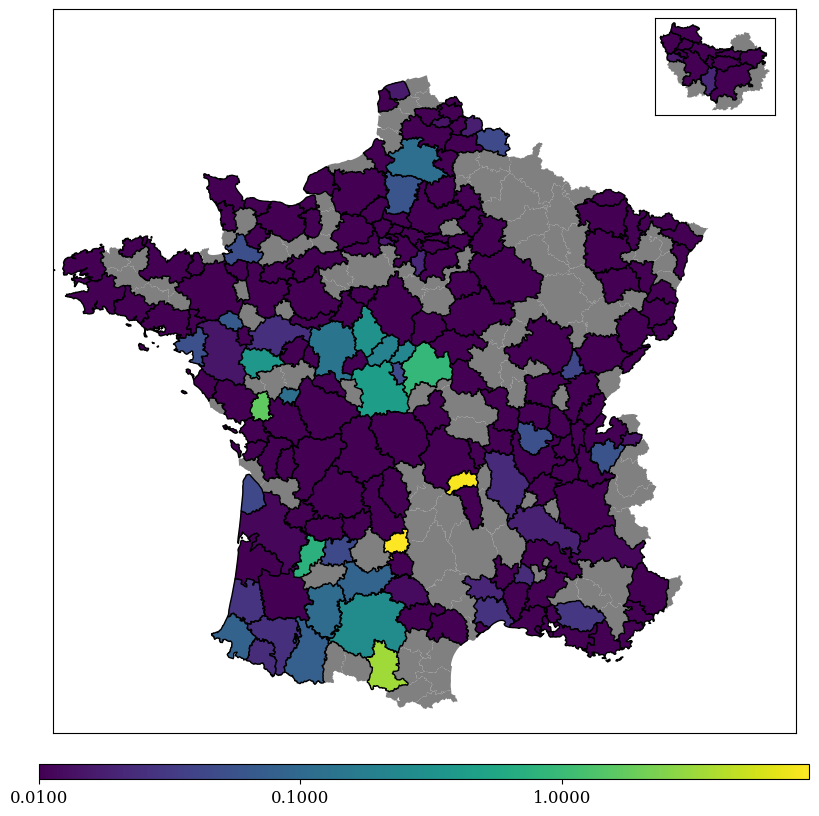

In [21]:

A_r = df.copy()
A_r = A_r
A_r = w_sr_d_sr.merge(A_r,how = "outer",indicator= True, left_on = ['A129',"ze2010"],right_on = ['A129',"ze2010_r_prime"])
A_r.w_srd_r_2.fillna(0,inplace = True)


A_r['w_sr_2'] = A_r.w_sr**2
A_r['w_d_sr_2'] = A_r.w_d_sr**2
#A_r['w_srd_r_2'] = A_r.w_srd_r**2
A_r['prod_w'] = A_r.w_sr_2*A_r.w_d_sr_2*A_r.w_srd_r_2
A_r = A_r.groupby(["ze2010"]).agg({"prod_w":"sum","w_sr_2":"sum"}).reset_index()
A_r['A_r'] = A_r.prod_w/A_r.w_sr_2*100


fig,axs = plt.subplots(1,1,figsize = (15,10))
plot_map(A_r, "A_r",axs,fig)

In [20]:

def plot_map(df,col_name,ax,fig):

    tmp = france.merge(df,on = "ze2010",how = "left")
    tmp[col_name].fillna(0,inplace = True)    
    vmin = 0.01#min(df.query(col_name+' >0')[col_name].to_list())#+df.query('sim_pi_r >0')["sim_pi_r"].to_list())
    vmax = max(df[col_name].to_list())
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    

    tmp.query(col_name+' == 0').plot(color = "gray",ax=ax)
    tmp.query(col_name+' > 0').plot(column = col_name,ax=ax,norm = norm, cmap = "viridis",edgecolor ="black")

    ax_inset = inset_axes(ax, width="65%", height="65%", loc="upper right",bbox_to_anchor=(0.745, 0.775, 0.25, 0.25), bbox_transform=ax.transAxes, borderpad=1)  
    data_idf = tmp[tmp['ze2010'].isin(idf_ze)]
    data_idf.query(col_name+' == 0').plot(color = "gray",ax=ax_inset)
    data_idf.query(col_name+' > 0').plot(column = col_name,ax=ax_inset,norm = norm, cmap = "viridis",edgecolor ="black")

    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax.set_xlim(-5, 10)
    ax.set_ylim(42, 52)
    ax.set_xticks([])
    ax.set_yticks([])

    add_colorbar(ax,fig,norm)
    return norm


,A129,ze2010,w_sr,w_d_sr,ze2010_r_prime,ze2010_r,w_srd_r,_merge
0,C10A,0050,0.205885,0.0,NaN,NaN,0.0,left_only
1,C10A,0051,0.037303,0.0,NaN,NaN,0.0,left_only
2,C10A,0052,0.011244,0.0,NaN,NaN,0.0,left_only
3,C10A,0053,0.028327,0.0,NaN,NaN,0.0,left_only
4,C10A,0054,0.055195,0.0,NaN,NaN,0.0,left_only
...,...,...,...,...,...,...,...,...
24475,N82Z,9313,0.002481,0.0,NaN,NaN,0.0,left_only
24476,N82Z,9314,0.003040,0.0,NaN,NaN,0.0,left_only
24477,N82Z,9315,0.019209,0.0,NaN,NaN,0.0,left_only
24478,N82Z,9316,0.005765,0.0,NaN,NaN,0.0,left_only


In [ ]:
w_srd_r = np.load(os.path.join(folder,"w_srd_r.npy")) # S x R' x R
upstream_A129_region = pd.read_csv(os.path.join(input_folder,"upstream_A129_region.csv")).query('ze2010 != 9999')
upstream_A129_region['ze2010']  = upstream_A129_region.ze2010.astype(str).str.zfill(4)
df = filter_N_upstream_df[['A129',"ze2010"]].merge(filter_N_upstream_df[['A129',"ze2010"]],on = ['A129'],suffixes = ['_r_prime','_r'])
df["w_srd_r"] = np.ndarray.flatten(w_srd_r)




In [38]:
df.A129.unique()

array(['C22B', 'C25D', 'C26E', 'C27B', 'C28A', 'C30C', 'C33Z', 'M70Z',
       'M71Z'], dtype=object)

In [44]:
w_srd_r[0,6]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 9.43792145e-02, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.35262872e-01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.47121857e-02,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.72690092e-02, 0.00000000e+00, 1.98487146e-02,
       0.00000000e+00, 9.93196329e-02, 3.86260388e-01, 0.00000000e+00,
       3.50439693e-04, 2.09072128e-02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.69033075e-03, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

,A129,ze2010_r_prime,ze2010_r,w_srd_r
1638,C22B,0056,0056,0.094379
1643,C22B,0056,1101,0.335263
1647,C22B,0056,1105,0.014712
1653,C22B,0056,1111,0.027269
1655,C22B,0056,1113,0.019849
...,...,...,...,...
664760,M71Z,9313,9310,0.275797
664828,M71Z,9314,2408,0.210197
665028,M71Z,9314,9305,0.756597
665032,M71Z,9314,9310,0.033179


In [ ]:
df = upstream_A129_region.sort_values(by = ['A129',"ze2010"])
df = df.merge(df,on = ['A129'],suffixes = ['_r_prime',"_r"])


,A129,ze2010_r_prime,ze2010_r
0,C22B,0053,0053
1,C22B,0053,0056
2,C22B,0053,0060
3,C22B,0053,0061
4,C22B,0053,1101
...,...,...,...
139078,M71Z,9315,9310
139079,M71Z,9315,9311
139080,M71Z,9315,9313
139081,M71Z,9315,9314


# Suppliers map

array([[0.  , 0.  , 0.02, ..., 0.02, 0.02, 0.  ],
       [0.  , 0.  , 0.  , ..., 0.04, 0.  , 0.  ],
       [0.  , 0.02, 0.  , ..., 0.02, 0.  , 0.  ],
       ...,
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.06, 0.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.04, 0.  , 0.  ]], shape=(9, 272))

/tmp/ipykernel_99855/2731473759.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sim_suppliers"] = np.ndarray.flatten(sim_suppliers)


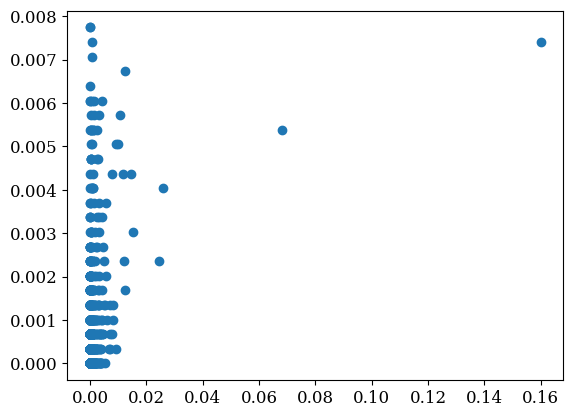

In [39]:
sim_suppliers = np.load(os.path.join(folder,"suppliers.npy")) # S x R' x R
sim_suppliers = sim_suppliers.astype(int)
sim_suppliers = np.sum(sim_suppliers,axis = 1)/np.sum(sim_suppliers)
emp_suppliers = np.load(os.path.join(input_folder,"N_rs.npy")) # Number of upstream per region. 

upstream_A129_region = pd.read_csv(os.path.join(input_folder,"upstream_A129_region.csv")).query('ze2010 != 9999')
upstream_A129_region['ze2010']  = upstream_A129_region.ze2010.astype(str).str.zfill(4)
df = filter_N_upstream_df[['A129',"ze2010"]]
df["sim_suppliers"] = np.ndarray.flatten(sim_suppliers)
df["emp_suppliers"] = np.ndarray.flatten(emp_suppliers)/np.sum(emp_suppliers)
df["N_rs"] = np.ndarray.flatten(emp_suppliers)
plt.scatter(df.emp_suppliers,df.sim_suppliers)

In [40]:
df.sort_values(by = 'emp_suppliers')

,A129,ze2010,sim_suppliers,emp_suppliers,N_rs
1783,C33Z,5212,0.000000,0.000000,0.0
1772,C33Z,5201,0.000673,0.000000,0.0
1771,C33Z,4309,0.000000,0.000000,0.0
1065,C27B,9108,0.000000,0.000000,0.0
1064,C27B,9106,0.000337,0.000000,0.0
...,...,...,...,...,...
2186,M71Z,0061,0.003029,0.015306,1789.0
2402,M71Z,8214,0.002356,0.024468,2860.0
2130,M70Z,8214,0.004039,0.025931,3031.0
2187,M71Z,1101,0.005385,0.068016,7950.0


NameError: name 'N_rs' is not defined